# Clasificación multiclase One-vs-All con Regresión Logística
## Dataset: Devanagari Character Set

**Integrante:** Espinoza Chiri Soledad Griselda

Se reutilizan las funciones desarrolladas en los cuadernillos de clase de one-vs-all (`sigmoid`, `lrCostFunction`, `oneVsAll`, `predictOneVsAll`, `displayData`), aplicadas ahora al dataset de caracteres manuscritos Devanagari: 92,000 imágenes en escala de grises de 32x32 píxeles, distribuidas en 46 clases balanceadas (2000 ejemplos por clase).

Fuente del dataset: https://www.kaggle.com/datasets/rishianand/devanagari-character-set


## 1. Librerías


In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy import optimize
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

%matplotlib inline


## 2. Carga del dataset con Pandas

El archivo `data.csv` tiene 1024 columnas de píxeles (imagen 32x32 aplanada) más la columna `character` con la etiqueta.


In [2]:
df = pd.read_csv('data.csv')
print(df.shape)
df.head()


(92000, 1025)


   pixel_0000  pixel_0001  ...  pixel_1023          character0           0           0  ...           0   character_01_ka1           0           0  ...           0   character_01_ka[5 rows x 1025 columns]

## 3. Balance de clases


In [3]:
conteo = df['character'].value_counts()
print('numero de clases:', conteo.shape[0])
print('min/max ejemplos por clase:', conteo.min(), conteo.max())


numero de clases: 46
min/max ejemplos por clase: 2000 2000


El dataset está perfectamente balanceado: 2000 ejemplos por cada una de las 46 clases.


## 4. Preprocesamiento

Se separan los píxeles (`X`) de la etiqueta (`y`). Los píxeles (0-255) se normalizan a [0,1] y las etiquetas de texto se codifican como enteros 0..45 (equivalente a como en clase se hacía `y[y==10]=0`, aquí con `pd.factorize`).


In [4]:
X = df.iloc[:, :-1].values.astype(np.float64) / 255.0
y, clases_unicas = pd.factorize(df['character'], sort=True)

input_layer_size = X.shape[1]   # 1024 (32x32)
num_labels = len(clases_unicas) # 46

m = y.size
print('X:', X.shape, ' y:', y.shape, ' num_labels:', num_labels)


X: (92000, 1024)  y: (92000,)  num_labels: 46


## 5. displayData (igual que en clase)

Función para visualizar ejemplos de imágenes almacenadas como filas de `X`.


In [5]:
def displayData(X, example_width=None, figsize=(10, 10)):
    """
    Muestra datos 2D almacenados en X en una cuadricula.
    """
    if X.ndim == 2:
        m, n = X.shape
    elif X.ndim == 1:
        n = X.size
        m = 1
        X = X[None]
    example_width = example_width or int(np.round(np.sqrt(n)))
    example_height = n // example_width

    display_rows = int(np.floor(np.sqrt(m)))
    display_cols = int(np.ceil(m / display_rows))

    fig, ax_array = plt.subplots(display_rows, display_cols, figsize=figsize)
    fig.subplots_adjust(wspace=0.025, hspace=0.025)
    ax_array = [ax_array] if m == 1 else ax_array.ravel()

    for i, ax in enumerate(ax_array):
        if i < m:
            ax.imshow(X[i].reshape(example_width, example_height, order='F'),
                      cmap='Greys', extent=[0, 1, 0, 1])
        ax.axis('off')


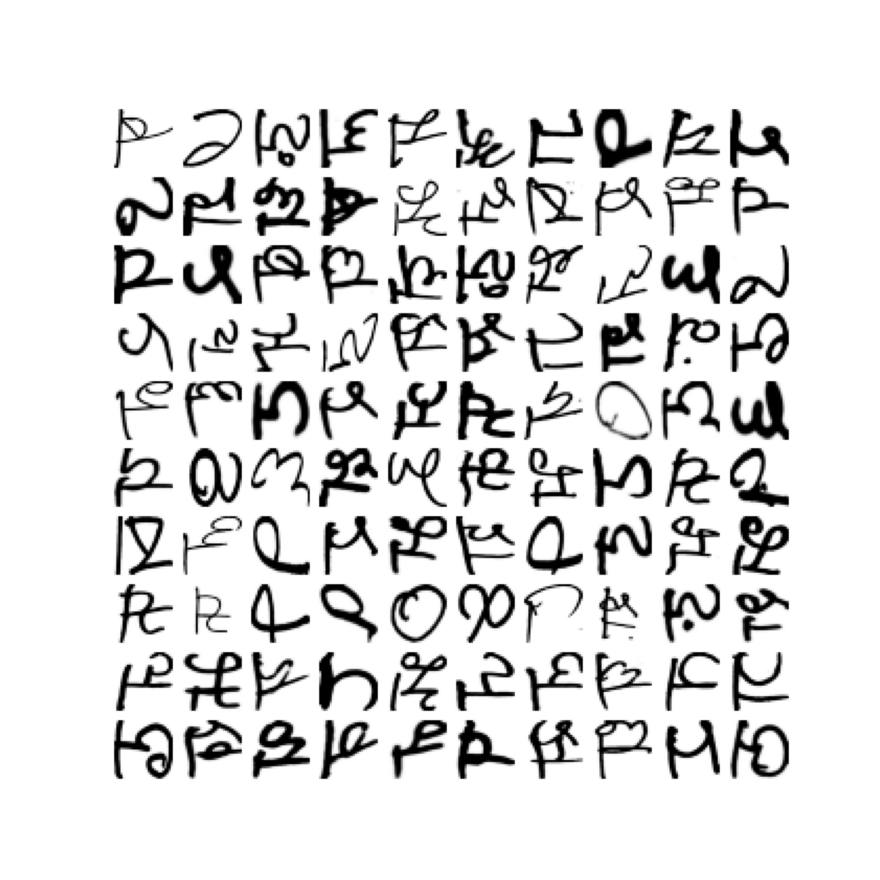

In [6]:
np.random.seed(1)
muestra = np.random.choice(m, 100, replace=False)
displayData(X[muestra, :], example_width=32, figsize=(8,8))


## 6. División entrenamiento (80%) / prueba (20%)

Se usa `train_test_split` con `stratify=y` para mantener la proporción de clases en ambos conjuntos. Los datos de prueba no se usan en el entrenamiento.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print('Entrenamiento:', X_train.shape, ' Prueba:', X_test.shape)


Entrenamiento: (73600, 1024)  Prueba: (18400, 1024)


## 7. Funciones del modelo (idénticas a las de los cuadernillos de clase)

### sigmoid, lrCostFunction

$$ g(z) = \frac{1}{1+e^{-z}} $$

$$ J(\theta) = \frac{1}{m}\sum_{i=1}^m\Big[-y^{(i)}\log(h_\theta(x^{(i)})) - (1-y^{(i)})\log(1-h_\theta(x^{(i)}))\Big] + \frac{\lambda}{2m}\sum_{j=1}^n \theta_j^2 $$


In [8]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def lrCostFunction(theta, X, y, lambda_):
    m = y.size
    h = sigmoid(X.dot(theta))
    temp = theta.copy()
    temp[0] = 0
    J = -(1/m) * np.sum(y*np.log(h) + (1-y)*np.log(1-h)) + (lambda_/(2*m)) * np.sum(temp**2)
    grad = (1/m) * (X.T.dot(h - y)) + (lambda_/m) * temp
    return J, grad


### oneVsAll

Entrena `num_labels` clasificadores de regresión logística (uno por clase), usando `scipy.optimize.minimize` con método `CG`, igual que en el cuadernillo de clase. Se añade un `callback` para registrar el costo en cada iteración y así poder graficar la curva de convergencia de cada uno de los 46 clasificadores.


In [9]:
def oneVsAll(X, y, num_labels, lambda_, maxiter=50):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))
    cost_history = [[] for _ in range(num_labels)]

    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    for c in np.arange(num_labels):
        initial_theta = np.zeros(n + 1)
        y_c = (y == c)

        def callback(xk, X=X, y_c=y_c, lambda_=lambda_, c=c):
            J, _ = lrCostFunction(xk, X, y_c, lambda_)
            cost_history[c].append(J)

        options = {'maxiter': maxiter}
        res = optimize.minimize(lrCostFunction,
                                 initial_theta,
                                 (X, y_c, lambda_),
                                 jac=True,
                                 method='CG',
                                 options=options,
                                 callback=callback)
        all_theta[c] = res.x

    return all_theta, cost_history


## 8. Entrenamiento del modelo (46 clasificadores, one-vs-all)


In [10]:
lambda_ = 1.0
all_theta, cost_history = oneVsAll(X_train, y_train, num_labels, lambda_, maxiter=50)
print(all_theta.shape)


clase  0 (character_01_ka     ) costo_final=0.03525 nit=50
clase  1 (character_02_kha    ) costo_final=0.05587 nit=50
...
clase 44 (digit_8             ) costo_final=0.00825 nit=50
clase 45 (digit_9             ) costo_final=0.01621 nit=50
(46, 1025)


## 9. Gráfico de costo: curva de convergencia de cada uno de los 46 clasificadores


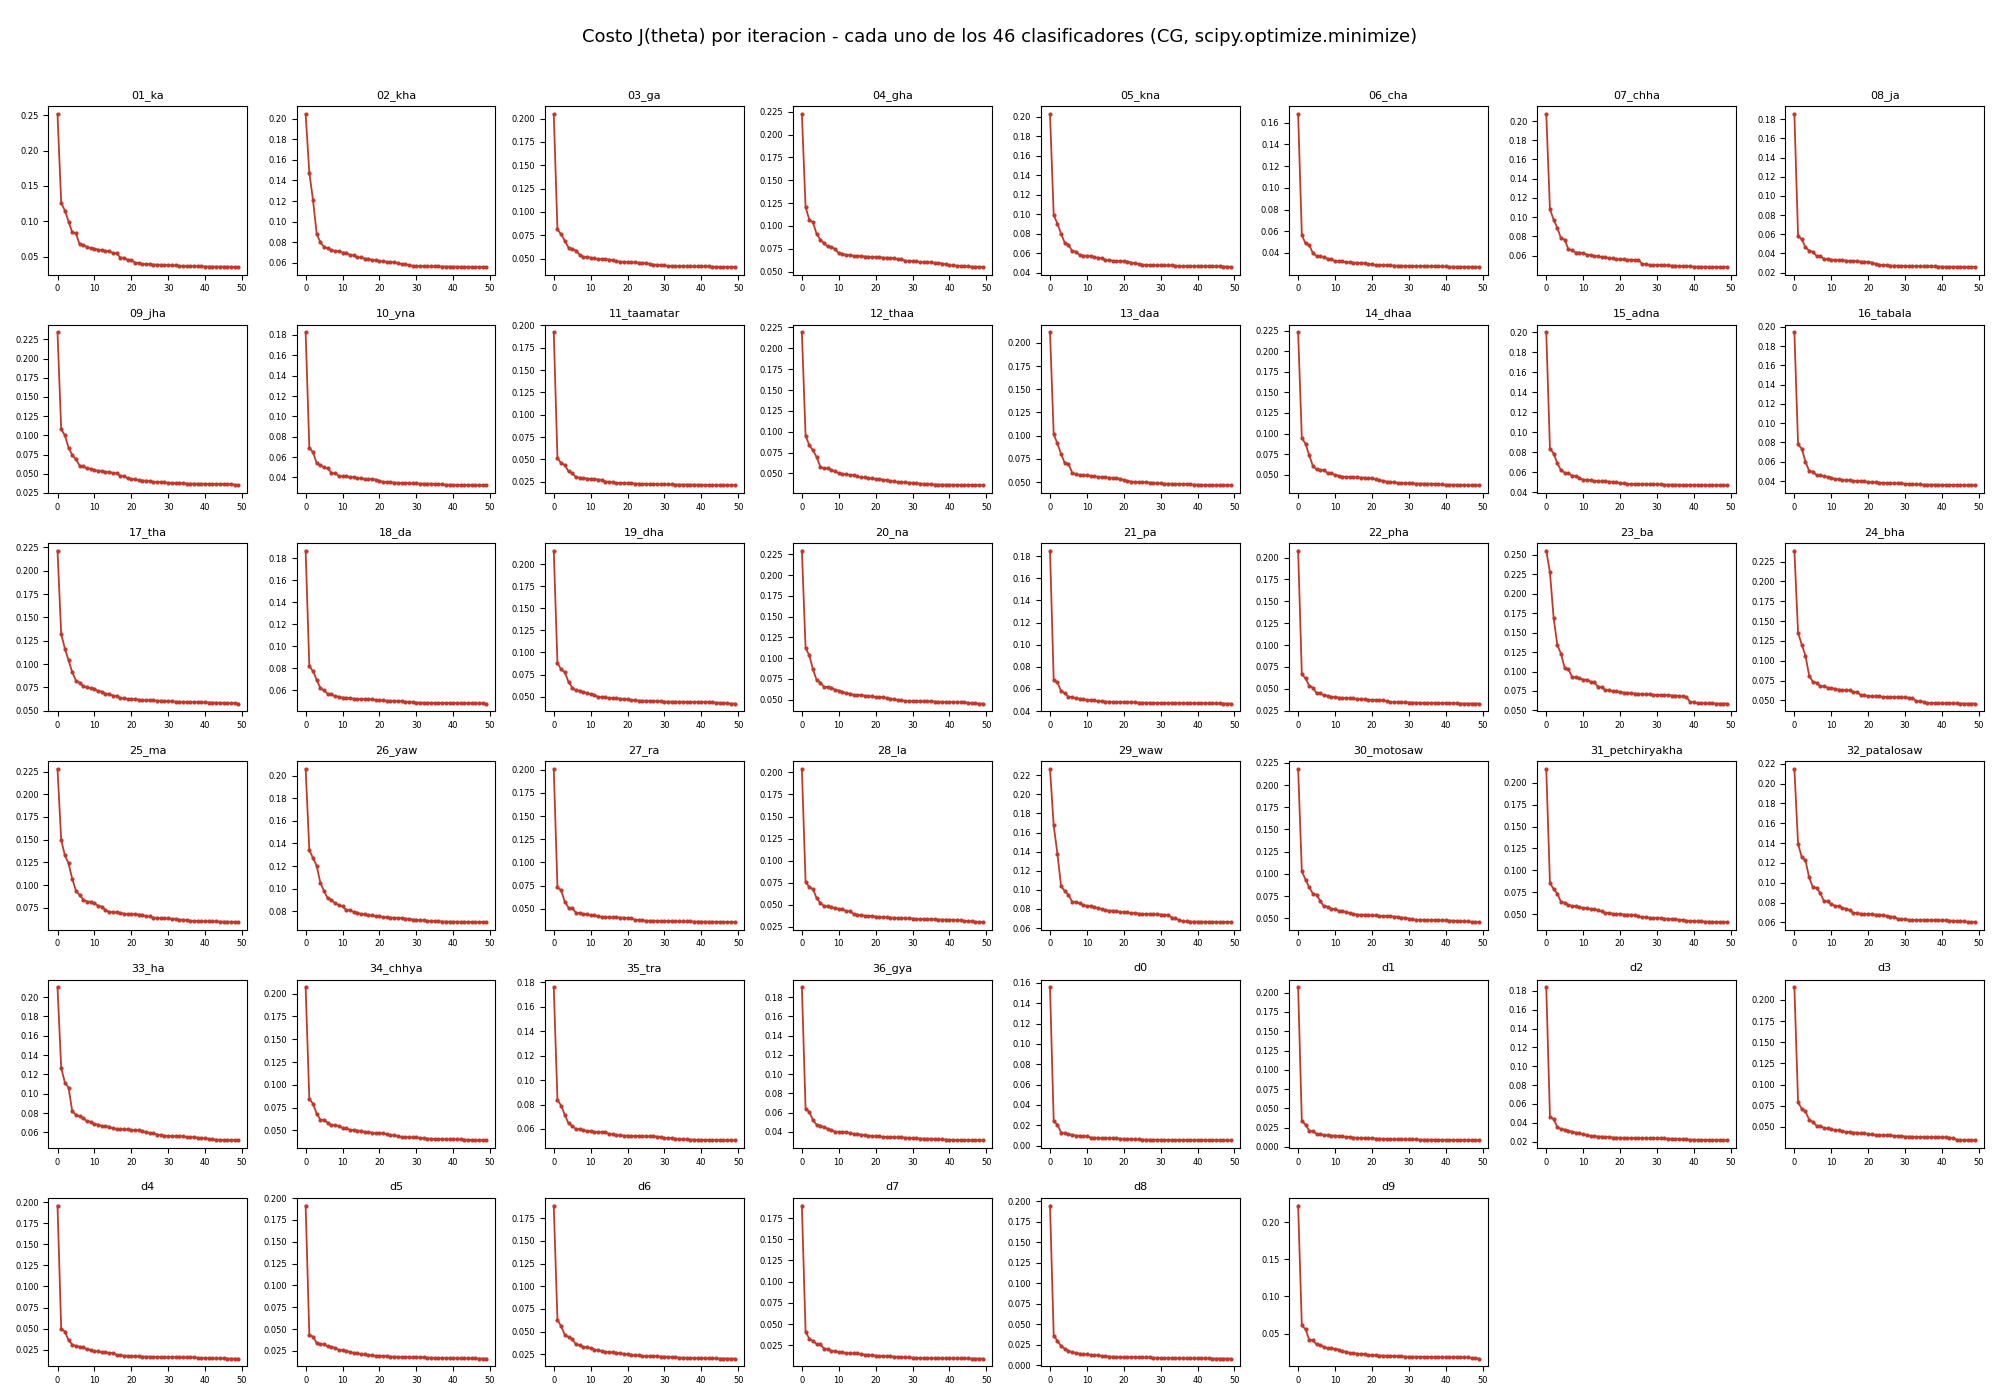

In [11]:
nombres_cortos = [c.replace('character_','').replace('digit_','d') for c in clases_unicas]

fig, axes = plt.subplots(6, 8, figsize=(20,14))
axes = axes.ravel()
for k in range(num_labels):
    axes[k].plot(cost_history[k], color='#c0392b', linewidth=1.3, marker='o', markersize=2)
    axes[k].set_title(nombres_cortos[k], fontsize=8)
    axes[k].tick_params(labelsize=6)
for k in range(num_labels, len(axes)):
    axes[k].axis('off')
fig.suptitle('Costo J(theta) por iteracion - cada uno de los 46 clasificadores (CG)', fontsize=13)
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()


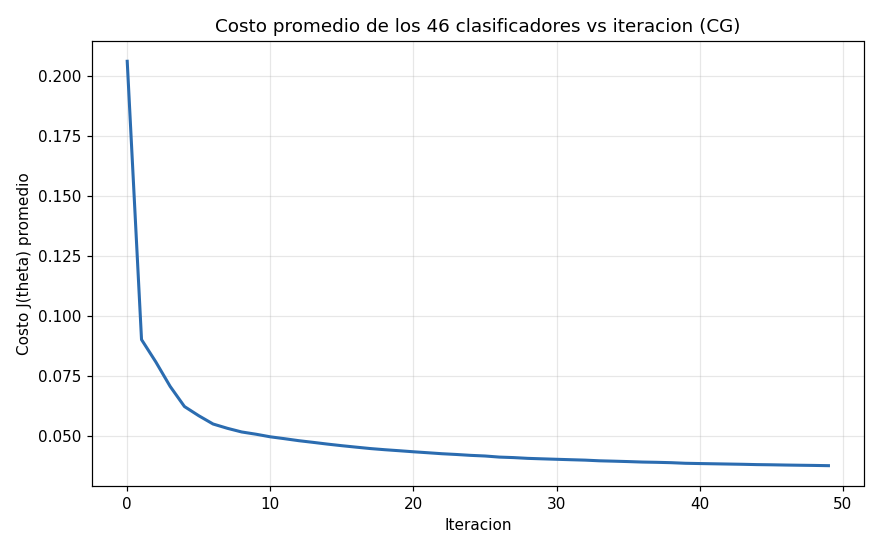

In [12]:
max_len = max(len(c) for c in cost_history)
mat = np.full((num_labels, max_len), np.nan)
for k in range(num_labels):
    mat[k, :len(cost_history[k])] = cost_history[k]
promedio = np.nanmean(mat, axis=0)

plt.figure(figsize=(8,5))
plt.plot(promedio, color='#2b6cb0', linewidth=2)
plt.title('Costo promedio de los 46 clasificadores vs iteracion (CG)')
plt.xlabel('Iteracion')
plt.ylabel('Costo J(theta) promedio')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Todos los 46 clasificadores convergen de forma estable en las primeras iteraciones, sin señales de divergencia.


## 10. predictOneVsAll y evaluación

Igual que en el cuadernillo de clase: se calcula la probabilidad de pertenecer a cada clase y se elige la de mayor probabilidad (`argmax`).


In [13]:
def predictOneVsAll(all_theta, X):
    m = X.shape[0]
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis=1)
    return p


In [14]:
pred_train = predictOneVsAll(all_theta, X_train)
pred_test = predictOneVsAll(all_theta, X_test)

print('Precision del conjunto de entrenamiento: {:.2f}%'.format(np.mean(pred_train == y_train) * 100))
print('Precision del conjunto de prueba: {:.2f}%'.format(np.mean(pred_test == y_test) * 100))


Precision del conjunto de entrenamiento: 75.32%
Precision del conjunto de prueba: 71.67%


La precisión de entrenamiento (75.32%) y de prueba (71.67%) son cercanas, lo que indica que el modelo generaliza razonablemente bien a datos no vistos, sin sobreajuste importante. Dado que es un modelo lineal enfrentando 46 clases de caracteres manuscritos con trazos similares entre sí, el resultado demuestra la efectividad del enfoque one-vs-all.


## 11. Precisión por clase (conjunto de prueba)


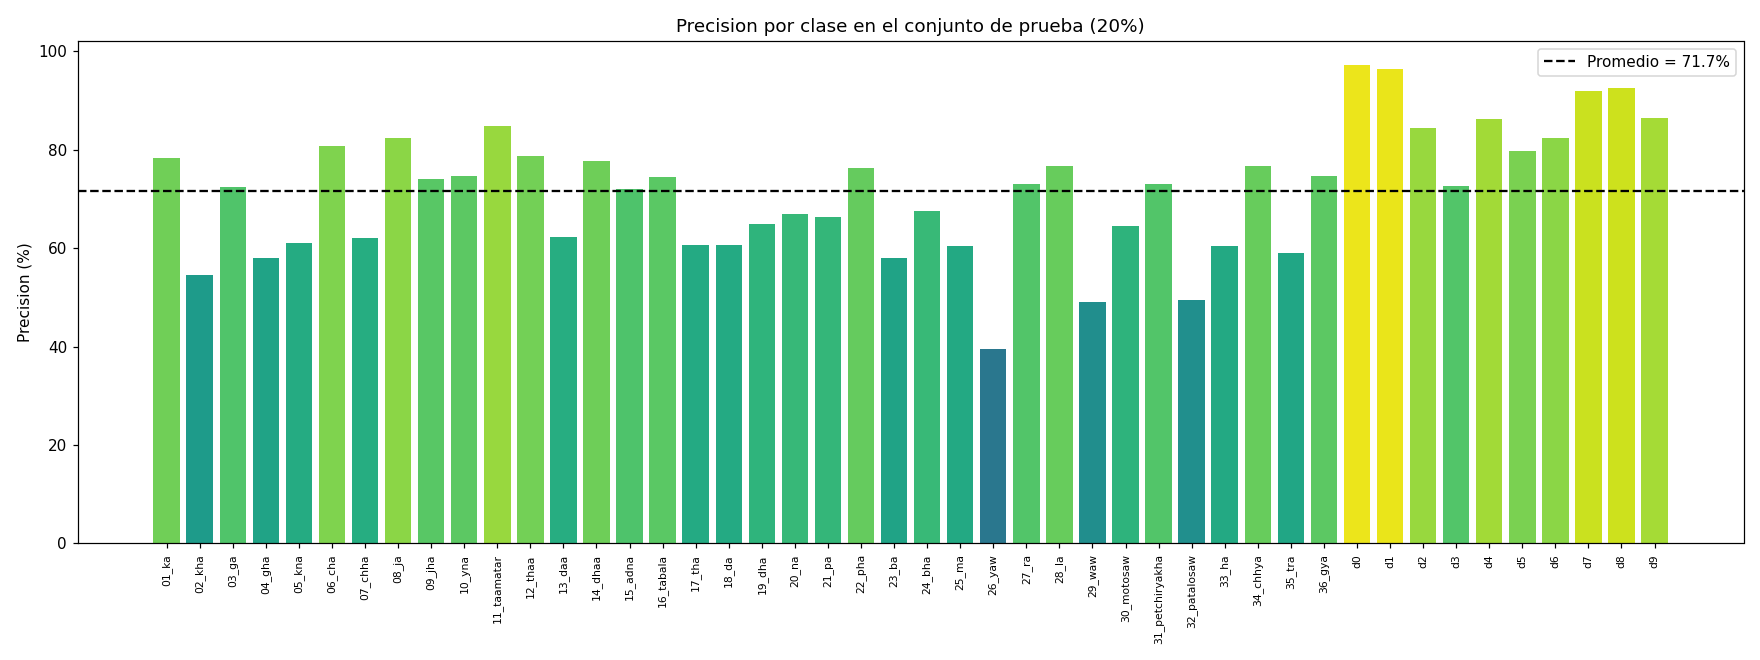

In [15]:
precision_por_clase = np.array([np.mean(pred_test[y_test==k]==k)*100 for k in range(num_labels)])

plt.figure(figsize=(16,6))
colores = plt.cm.viridis(precision_por_clase/100)
plt.bar(range(num_labels), precision_por_clase, color=colores)
plt.xticks(range(num_labels), nombres_cortos, rotation=90, fontsize=7)
plt.ylabel('Precision (%)')
plt.title('Precision por clase en el conjunto de prueba (20%)')
plt.axhline(precision_por_clase.mean(), color='black', linestyle='--',
            label=f'Promedio = {precision_por_clase.mean():.1f}%')
plt.legend()
plt.tight_layout()
plt.show()


## 12. Matriz de confusión


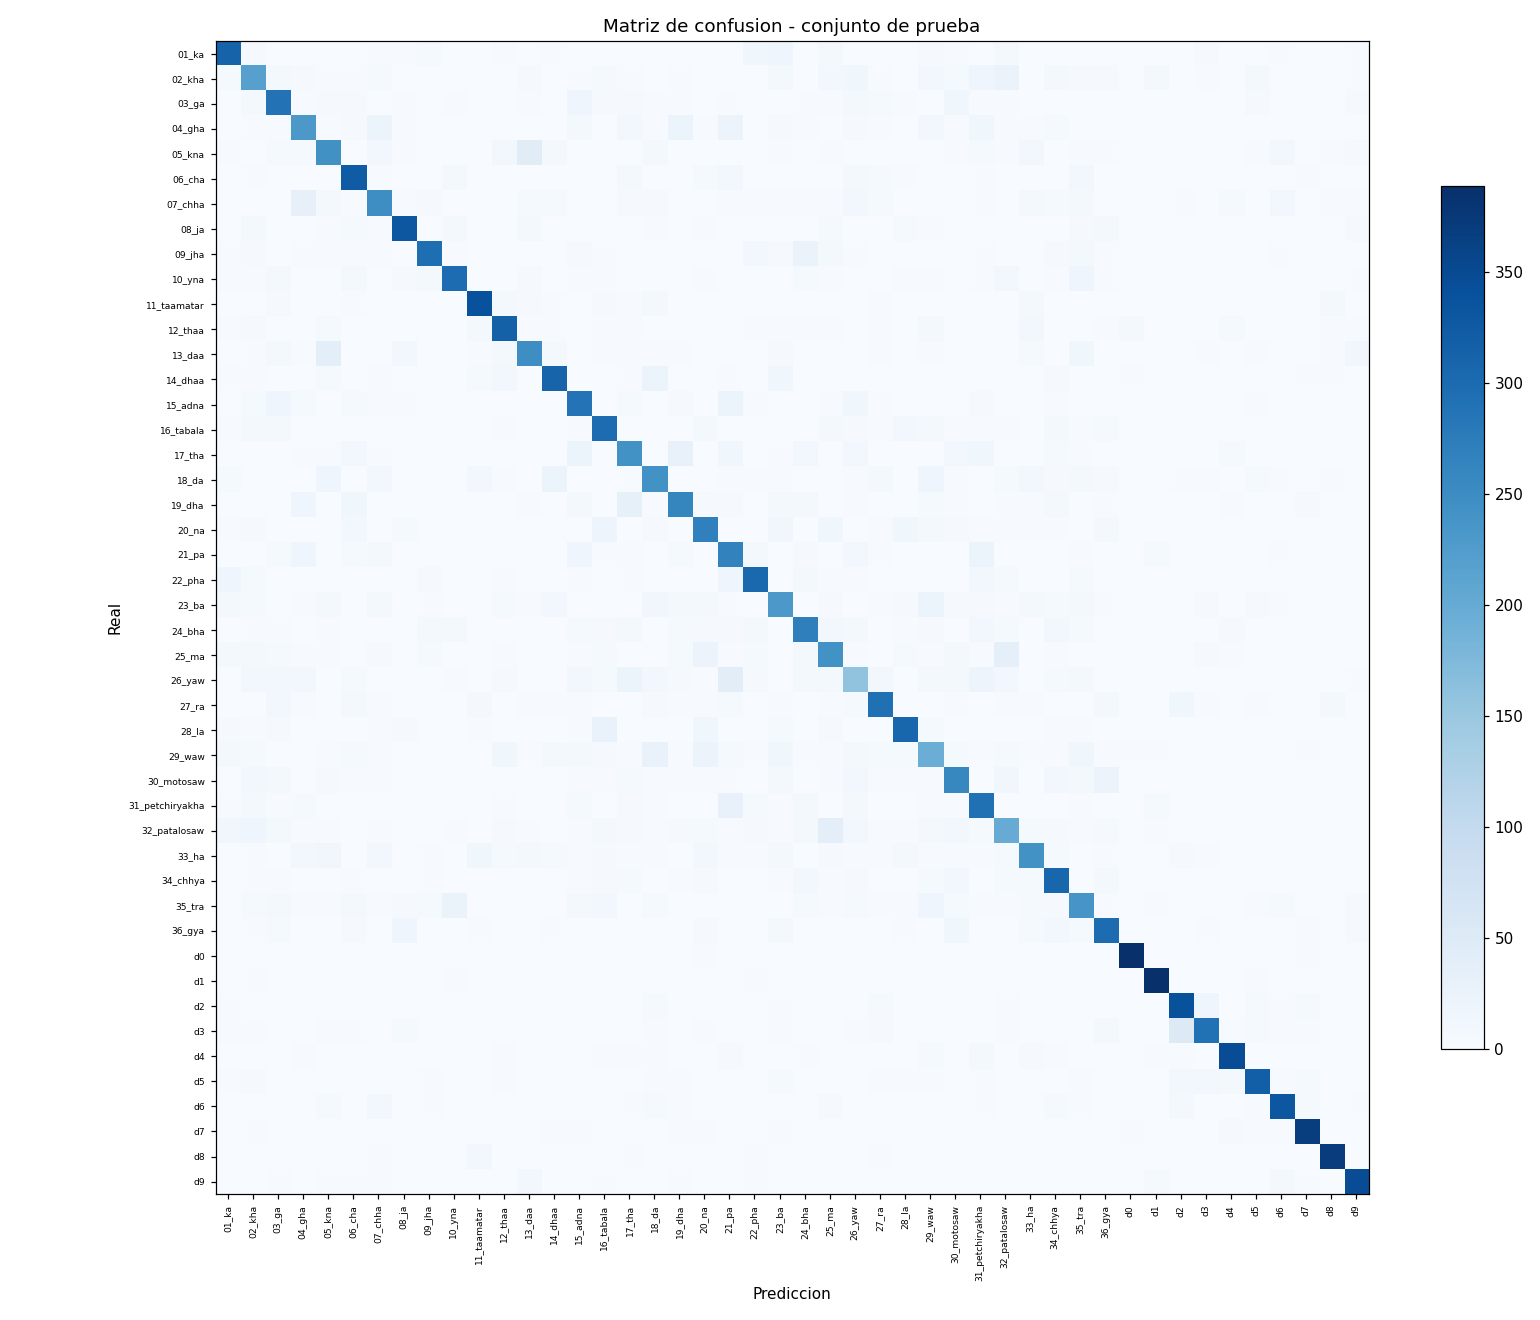

In [16]:
cm = confusion_matrix(y_test, pred_test, labels=range(num_labels))

plt.figure(figsize=(14,12))
plt.imshow(cm, cmap='Blues')
plt.colorbar(fraction=0.03)
plt.xticks(range(num_labels), nombres_cortos, rotation=90, fontsize=6)
plt.yticks(range(num_labels), nombres_cortos, fontsize=6)
plt.xlabel('Prediccion'); plt.ylabel('Real')
plt.title('Matriz de confusion - conjunto de prueba')
plt.tight_layout()
plt.show()


## 13. displayData: ejemplos de predicciones sobre imágenes reales


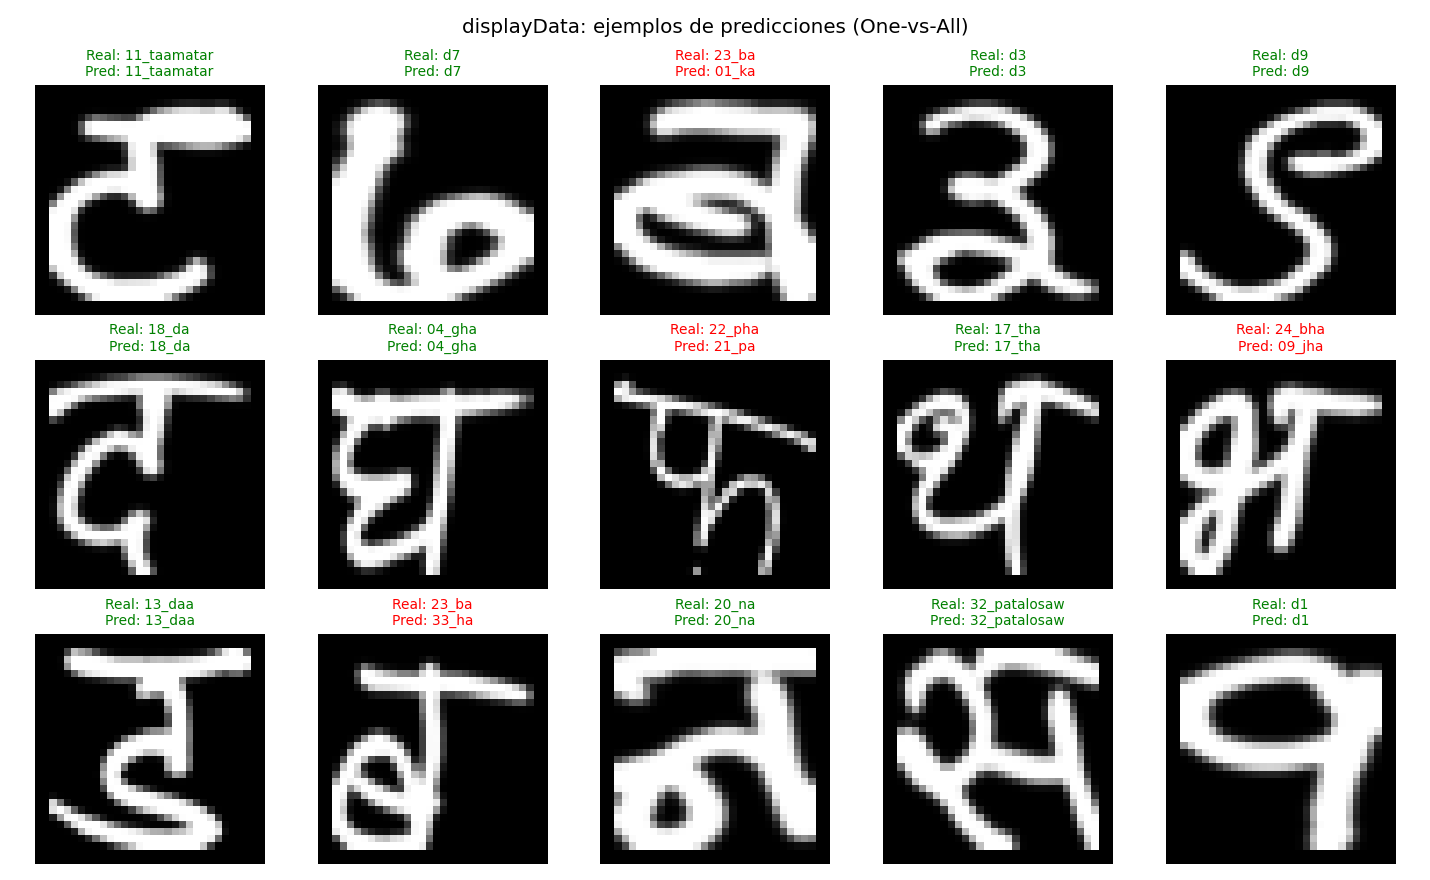

In [17]:
np.random.seed(7)
idxs = np.random.choice(len(y_test), 15, replace=False)

fig, axes = plt.subplots(3,5, figsize=(13,8))
axes = axes.ravel()
for i, idx in enumerate(idxs):
    img = X_test[idx].reshape(32,32)
    real = nombres_cortos[y_test[idx]]
    pred = nombres_cortos[pred_test[idx]]
    ok = y_test[idx] == pred_test[idx]
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'Real: {real}\nPred: {pred}', fontsize=9, color=('green' if ok else 'red'))
    axes[i].axis('off')
plt.suptitle('Ejemplos de predicciones (One-vs-All)', fontsize=13)
plt.tight_layout()
plt.show()


## 14. Conclusiones

- Se reutilizaron las mismas funciones vistas en clase para one-vs-all (`sigmoid`, `lrCostFunction`, `oneVsAll` con `scipy.optimize.minimize` método `CG`, `predictOneVsAll`, `displayData`), aplicándolas al dataset de caracteres Devanagari (92,000 imágenes 32x32, 46 clases balanceadas con 2000 ejemplos cada una), cumpliendo $m\ge 50000$ y resolución $\ge 20\times20$.
- Se aplicó Pandas para cargar, verificar el balance y preprocesar (normalización, codificación de etiquetas) el dataset.
- Se dividió el dataset en 80% entrenamiento (73,600) y 20% prueba (18,400), sin mezclar los datos de prueba en el entrenamiento.
- Se entrenaron los 46 clasificadores logísticos regularizados ($\lambda=1$, `maxiter=50`, método CG), obteniendo **75.32%** de precisión en entrenamiento y **71.67%** en prueba.
- Las gráficas de costo (individuales por clasificador y promedio) muestran una convergencia estable en todas las clases.
- La matriz de confusión y los ejemplos de `displayData` confirman visualmente la efectividad del modelo para distinguir entre los 46 caracteres.
